In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [21]:
df = pd.read_csv("Country-data.csv.xls")

In [22]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [23]:
df.shape

(167, 10)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [25]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


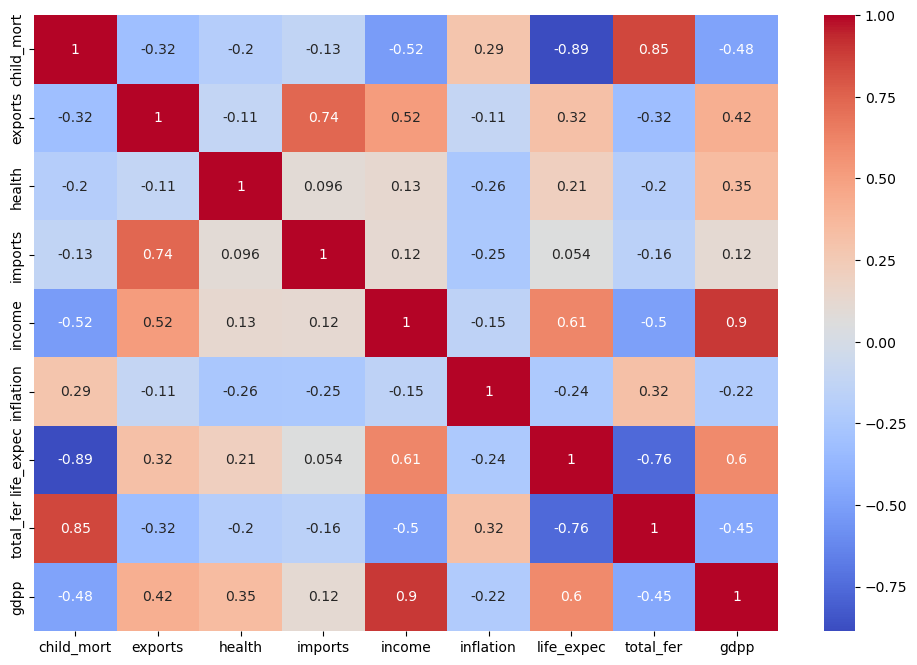

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

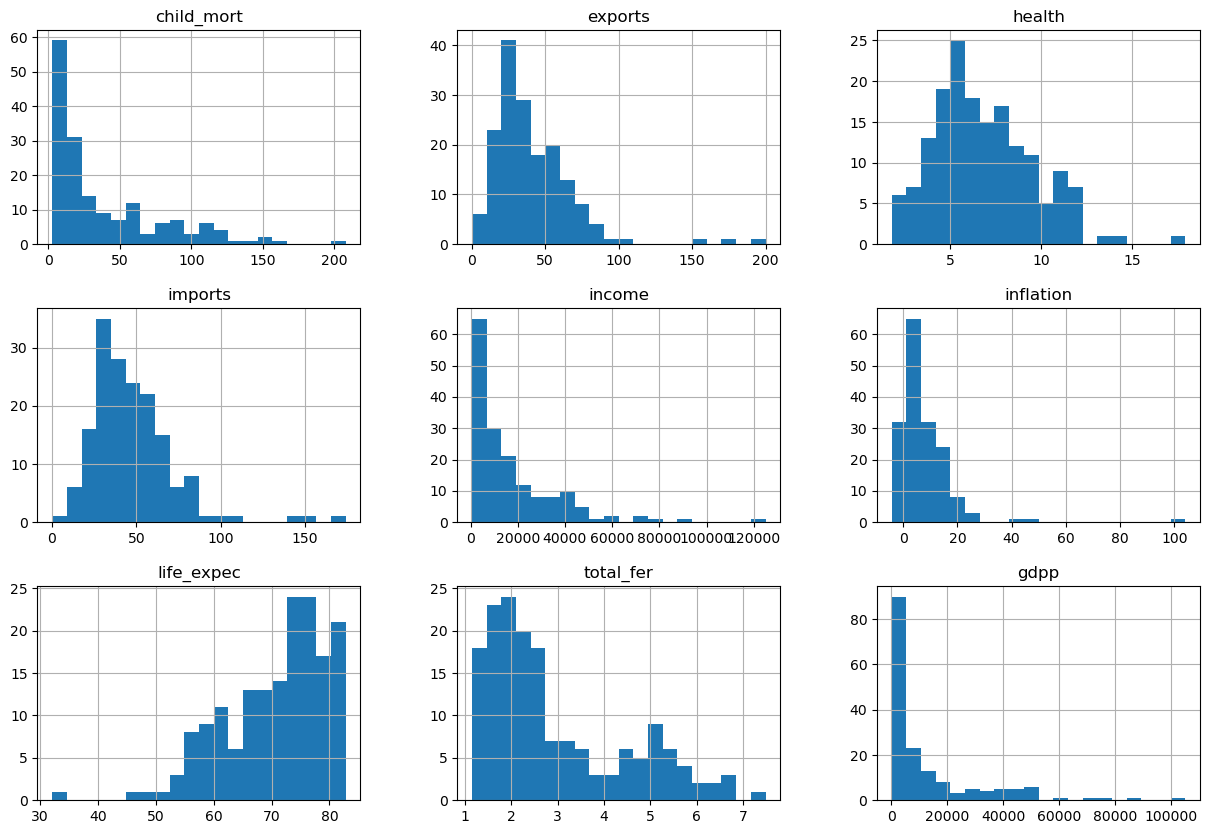

In [27]:
df.hist(
    figsize=(15,10),
    bins=20
)
plt.show()

In [28]:
import numpy as np

numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


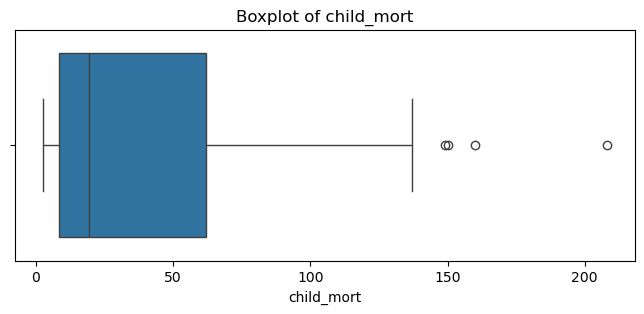

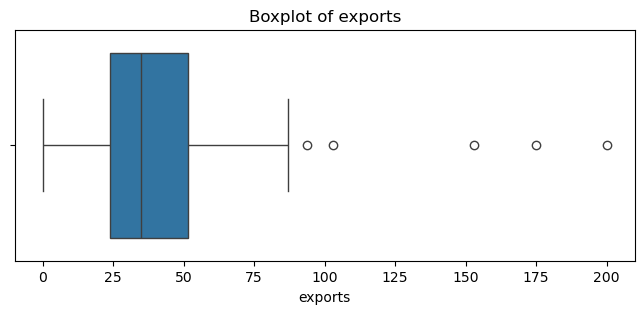

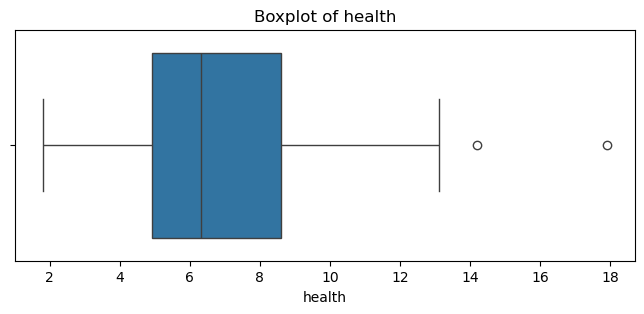

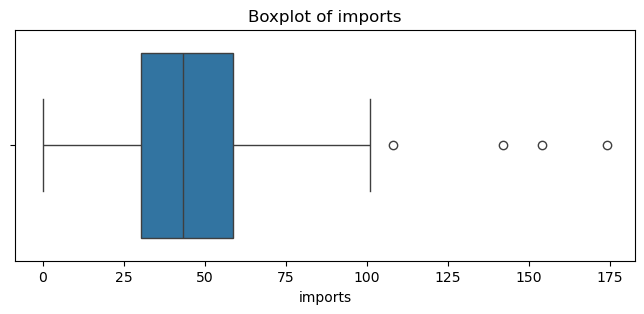

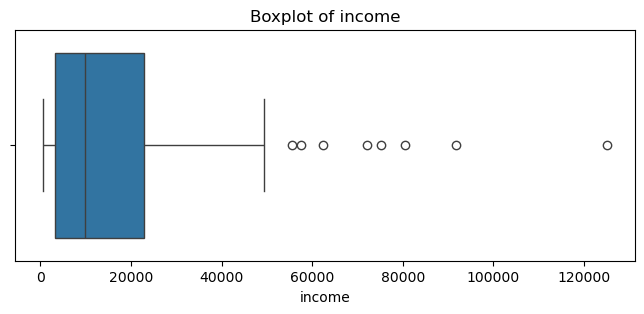

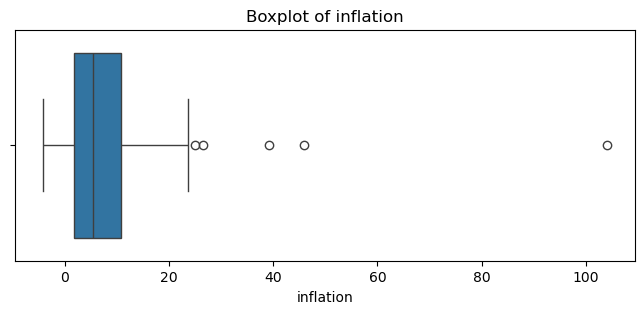

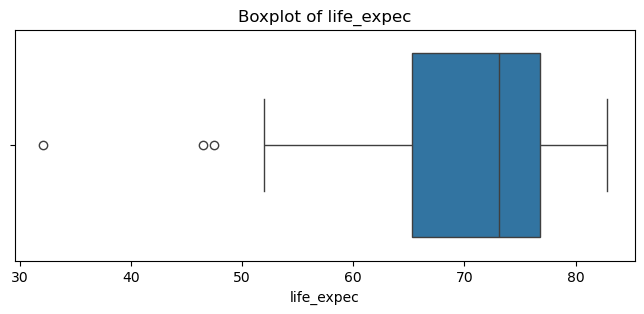

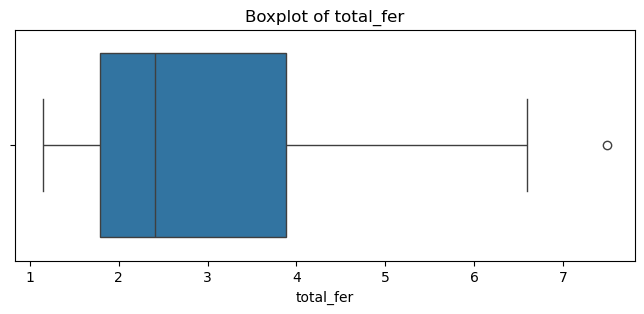

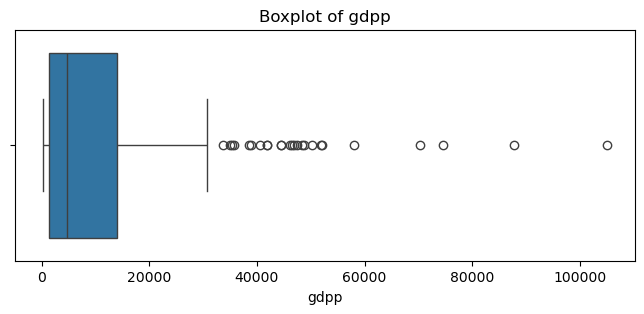

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_columns:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

In [30]:
X = df.drop("country", axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler())
])

X_scaled = pipeline.fit_transform(X)

print(X_scaled.shape)

(167, 9)


In [59]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_clusters = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_clusters

print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


In [32]:
from sklearn.cluster import KMeans

wcss=[]

for i in range(1,11):

    km=KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

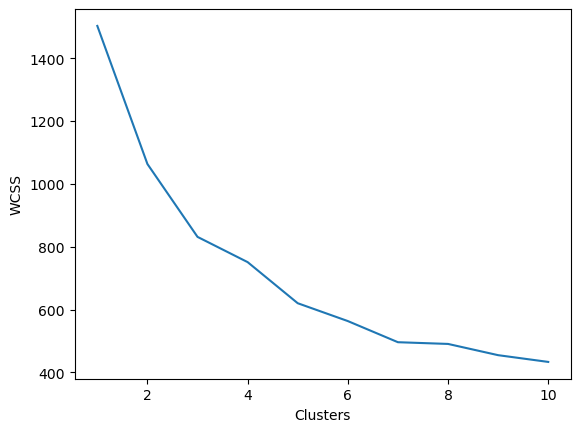

In [33]:
plt.plot(range(1,11),wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [34]:
kmeans=KMeans(
    n_clusters=3,
    random_state=42
)

clusters=kmeans.fit_predict(X_scaled)

df["Cluster"]=clusters

In [35]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)

pca_data=pca.fit_transform(X_scaled)

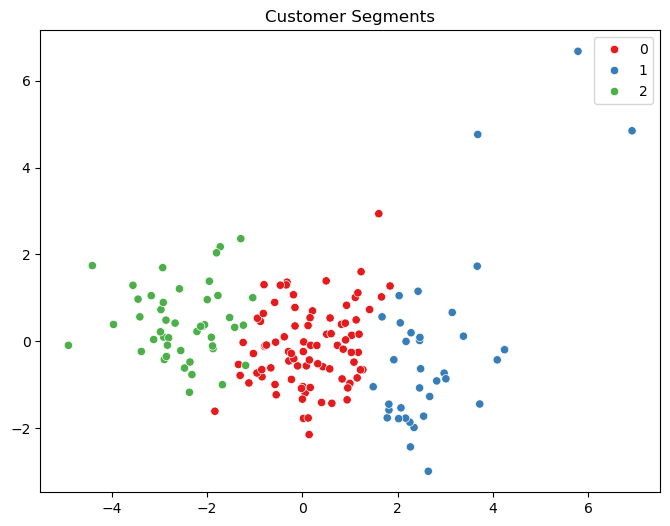

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_data[:,0],
    y=pca_data[:,1],
    hue=clusters,
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

In [37]:
def segment(gdp):

    if gdp < 3000:
        return 0

    elif gdp < 12000:
        return 1

    return 2

df["Target"]=df["gdpp"].apply(segment)

In [39]:
X = df.drop(["country", "Target"], axis=1)
y = df["Target"]

In [40]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()

lr.fit(X_train,y_train)

LogisticRegression()

In [42]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(
    max_depth=5
)

dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [44]:
from sklearn.ensemble import AdaBoostClassifier

ada=AdaBoostClassifier(
    n_estimators=200
)

ada.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=200)

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gb=GradientBoostingClassifier()

gb.fit(X_train,y_train)

GradientBoostingClassifier()

In [47]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 20.1 MB/s  0:00:00

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [48]:
from xgboost import XGBClassifier

xgb=XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [49]:
from sklearn.metrics import accuracy_score

print(
    accuracy_score(
        y_test,
        rf.predict(X_test)
    )
)

1.0


In [50]:
from sklearn.metrics import classification_report

print(
classification_report(
y_test,
rf.predict(X_test)
)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        10

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [52]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(
    y_test,
    rf.predict(X_test)
)
print(cm)

[[13  0  0]
 [ 0 11  0]
 [ 0  0 10]]


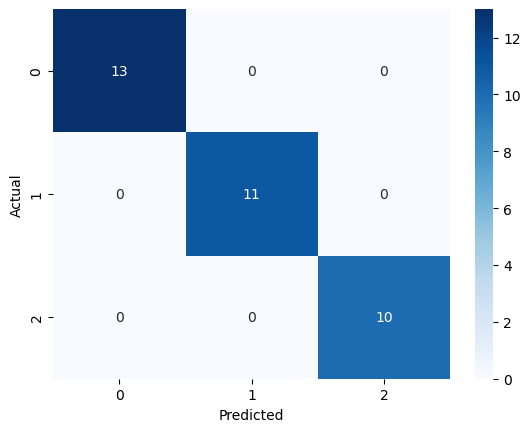

In [53]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

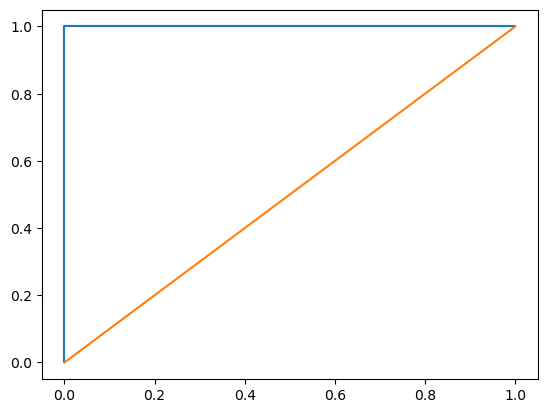

In [54]:
from sklearn.metrics import roc_curve

probs = rf.predict_proba(X_test)

fpr,tpr,_ = roc_curve(
    y_test,
    probs[:,1],
    pos_label=1
)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])
plt.show()

In [60]:
from sklearn.metrics import accuracy_score
import pandas as pd

lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
ada_pred = ada.predict(X_test)
gb_pred = gb.predict(X_test)

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ada_pred),
        accuracy_score(y_test, gb_pred)
    ]
}

try:
    xgb_pred = xgb.predict(X_test)
    results["Model"].append("XGBoost")
    results["Accuracy"].append(
        accuracy_score(y_test, xgb_pred)
    )
except:
    pass

comparison_df = pd.DataFrame(results)

comparison_df["Accuracy"] = (
    comparison_df["Accuracy"] * 100
).round(2)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df

,Model,Accuracy
1,Decision Tree,100.00
2,Random Forest,100.00
3,AdaBoost,100.00
4,Gradient Boosting,100.00
5,XGBoost,100.00
0,Logistic Regression,91.18


In [62]:
import joblib


joblib.dump(rf, "random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!
